# Development and internal validation of a preoperative prediction model for postoperative endoscopic thyroidectomy hypocalcemia

**Analysis notebook** — ICTMHS 2026. Implements the 7-step analysis plan agreed with the clinical team.

### Locked study decisions
| Item | Value |
|---|---|
| Design | Retrospective cohort |
| N | 78 patients |
| **Outcome** | Postoperative hypocalcemia = **postoperative serum calcium < 2.1 mmol/L** |
| Preoperative predictors | **(1) Pre-op PTH, (2) Pre-op calcium, (3) Pre-op vitamin D** |
| Descriptive covariates (not in model) | Age, sex, BMI |
| Candidate models | Standard logistic regression, **Firth** logistic regression, **LASSO** logistic regression |
| Internal validation | Bootstrap (B = 1000), Harrell optimism correction |

### The 7 steps
1. Data preparation (missingness, distributions, define outcome)
2. Descriptive analysis by hypocalcemia group
3. Group comparison (Mann-Whitney U, Fisher exact) — to look at *trend*, **not** to select variables
4. Build the 3 candidate models
5. Bootstrap internal validation → optimism-corrected AUC + 95% CI
6. Performance evaluation (AUC + CI, sensitivity/specificity, ROC, calibration, Brier)
7. Model comparison, selection, decision-curve analysis, final model

> **Reproducibility:** all randomness seeded (`SEED = 42`). State-of-the-art tooling: `scikit-learn`, `statsmodels`, `dcurves`, plus a dependency-free **Firth** implementation and **DeLong** AUC CIs. Sections end with **"Learnings & verdict"** blocks the clinical team can paste into the manuscript.

## 0. Environment & reproducibility

In [7]:
import warnings
warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import statsmodels.api as sm
from scipy.special import expit
from scipy.optimize import minimize
from scipy.stats import mannwhitneyu, shapiro, fisher_exact, norm
from sklearn.linear_model import LogisticRegressionCV
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score, roc_curve, brier_score_loss
from sklearn.calibration import calibration_curve
from dcurves import dca as dca_compute

SEED = 42
np.random.seed(SEED)
RNG = np.random.default_rng(SEED)

RAW = "Thyroid_Sx_research_(mock).csv"
PREDICTORS = ["Pre-op PTH", "Pre-op Ca", "Vit D(preop)"]
THRESH = 2.1          # mmol/L  -> hypocalcemia cutoff
B_BOOT = 1000         # bootstrap resamples for internal validation

plt.rcParams.update({"figure.dpi": 110, "figure.figsize": (5.2, 4.4),
                     "axes.grid": True, "grid.alpha": 0.3})
print("Environment ready.")

Environment ready.


### 0.1 Firth's bias-reduced logistic regression (dependency-free)

`firthlogist` is pinned to numpy < 2.0 and is incompatible with this environment, so we implement Firth's method directly. It penalises the log-likelihood by `+0.5*log|I(beta)|` (the Jeffreys invariant prior), which (a) removes the first-order finite-sample bias of maximum-likelihood logistic regression and (b) yields finite estimates under complete/quasi-complete separation — exactly the small-sample, rare-event setting of this study.

**References:** Firth D. *Biometrika* 1993;80(1):27-38. Heinze G, Schemper M. *Stat Med* 2002;21(16):2409-2419.

In [8]:
class FirthLogisticRegression:
    """Firth penalised logistic regression. sklearn-like API; adds its own intercept."""
    def __init__(self, max_iter=500, tol=1e-10):
        self.max_iter = max_iter
        self.tol = tol

    @staticmethod
    def _design(X):
        X = np.asarray(X, dtype=float)
        return np.column_stack([np.ones(len(X)), X])

    def _neg_penalised_loglik(self, beta, Xc, y):
        eta = np.clip(Xc @ beta, -30, 30)
        p = expit(eta)
        ll = np.sum(y * eta - np.logaddexp(0.0, eta))           # stable log-likelihood
        W = np.clip(p * (1 - p), 1e-12, None)
        XtWX = (Xc * W[:, None]).T @ Xc + np.eye(Xc.shape[1]) * 1e-10   # Fisher info I(beta)
        sign, logdet = np.linalg.slogdet(XtWX)
        if sign <= 0:                                            # guard against non-PD
            logdet = np.log(max(np.linalg.det(XtWX), 1e-300))
        return -(ll + 0.5 * logdet)                              # Firth = LL + 0.5*log|I|

    def fit(self, X, y):
        Xc = self._design(X)
        y = np.asarray(y, dtype=float)
        res = minimize(self._neg_penalised_loglik, np.zeros(Xc.shape[1]), args=(Xc, y),
                       method="BFGS", options={"maxiter": self.max_iter, "gtol": self.tol})
        self.beta_ = res.x
        self.converged_ = bool(res.success)
        self.intercept_, self.coef_ = self.beta_[0], self.beta_[1:]
        return self

    def predict_proba(self, X):
        p1 = expit(np.clip(self._design(X) @ self.beta_, -30, 30))
        return np.column_stack([1 - p1, p1])

### 0.2 State-of-the-art evaluation helpers

- **DeLong** variance / 95% CI for the AUC (Sun & Xu, *Comput Stat Data Anal* 2014), plus a paired test for comparing two AUCs on the same patients (DeLong et al. *Biometrics* 1988).
- **Calibration-in-the-large** (intercept), **calibration slope**, and the **Integrated Calibration Index (ICI)** via LOWESS (Austin PC et al. *Stat Med* 2020). Ideal calibration: intercept = 0, slope = 1, ICI ~ 0.

In [9]:
def _delong_components(y_true, y_score):
    y_true, y_score = np.asarray(y_true), np.asarray(y_score)
    pos, neg = y_score[y_true == 1], y_score[y_true == 0]
    m, n = len(pos), len(neg)
    v10 = np.array([np.sum(pos[i] > neg) + 0.5 * np.sum(pos[i] == neg) for i in range(m)]) / n
    v01 = np.array([np.sum(neg[i] < pos) + 0.5 * np.sum(neg[i] == pos) for i in range(n)]) / m
    return v10, v01, m, n

def delong_auc_ci(y_true, y_score, alpha=0.05):
    """AUC with DeLong 95% CI."""
    v10, v01, m, n = _delong_components(y_true, y_score)
    auc = v10.mean()
    var = v10.var(ddof=1) / m + v01.var(ddof=1) / n
    z = norm.ppf(1 - alpha / 2)
    return float(auc), float(auc - z * np.sqrt(var)), float(auc + z * np.sqrt(var))

def delong_paired_test(y_true, s1, s2):
    """Two-sided p for H0: AUC(s1) == AUC(s2) on the same patients."""
    v10_1, v01_1, m, n = _delong_components(y_true, s1)
    v10_2, v01_2, _, _ = _delong_components(y_true, s2)
    c10 = np.cov(v10_1, v10_2, ddof=1) / m
    c01 = np.cov(v01_1, v01_2, ddof=1) / n
    var_diff = c10[0, 0] + c01[0, 0] - 2 * (c10[0, 1] + c01[0, 1])
    lrc = (delong_auc_ci(y_true, s1)[0] - delong_auc_ci(y_true, s2)[0]) / np.sqrt(max(var_diff, 1e-30))
    return float(2 * norm.sf(abs(lrc)))

def calibration_metrics(y_true, p):
    """Recalibration intercept, slope, and ICI (Austin 2020).
    ICI uses a degree-3 polynomial-logistic smoother of outcome on logit(p).
    (LOWESS is avoided: statsmodels 0.14.x returns degenerate all-zero output for binary y.)"""
    y_true = np.asarray(y_true)
    p = np.clip(np.asarray(p), 1e-6, 1 - 1e-6)
    logit = np.log(p / (1 - p))
    try:
        r = sm.Logit(y_true, sm.add_constant(logit)).fit(disp=0, maxiter=200)
        cal_int, cal_slope = float(r.params[0]), float(r.params[1])
    except Exception:
        cal_int, cal_slope = np.nan, np.nan
    try:
        Xs = np.column_stack([logit, logit**2, logit**3])
        r2 = sm.Logit(y_true, sm.add_constant(Xs)).fit(disp=0, maxiter=200)
        ici = float(np.mean(np.abs(r2.predict(sm.add_constant(Xs)) - p)))
    except Exception:
        ici = np.nan
    return cal_int, cal_slope, ici

print("SOTA helpers ready.")

SOTA helpers ready.


### 0.3 Model wrappers

Each wrapper standardises predictors **inside** `fit`, so the bootstrap re-standardises on every resample — this is required for an honest optimism estimate (the entire modelling pipeline is rebuilt on each bootstrap sample). All wrappers expose the same `fit(X, y)` / `predict_proba(X)` / `.coef_std` / `.intercept` interface.

In [10]:
class StandardLR:
    """Maximum-likelihood logistic regression (statsmodels)."""
    def fit(self, X, y):
        self.mu, self.sd = X.mean(0), X.std(0)
        Xs = (X - self.mu) / self.sd
        try:
            self.res = sm.Logit(y, sm.add_constant(Xs)).fit(disp=0, maxiter=200)
        except Exception:
            self.res = sm.Logit(y, sm.add_constant(Xs)).fit(disp=0, method="bfgs", maxiter=1000)
        self.intercept, self.coef_std = float(self.res.params[0]), np.asarray(self.res.params[1:])
        return self
    def predict_proba(self, X):
        p = np.asarray(self.res.predict(sm.add_constant((X - self.mu) / self.sd)))
        return np.column_stack([1 - p, p])

class FirthLR:
    """Firth penalised logistic regression (section 0.1)."""
    def fit(self, X, y):
        self.mu, self.sd = X.mean(0), X.std(0)
        self.m = FirthLogisticRegression().fit((X - self.mu) / self.sd, y)
        self.intercept, self.coef_std = float(self.m.intercept_), self.m.coef_.copy()
        return self
    def predict_proba(self, X):
        return self.m.predict_proba((X - self.mu) / self.sd)

class LassoLR:
    """L1-penalised (LASSO) logistic regression; 5-fold stratified CV picks the penalty."""
    def fit(self, X, y):
        cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)
        self.pipe = Pipeline([
            ("sc", StandardScaler()),
            ("lr", LogisticRegressionCV(penalty="l1", solver="liblinear", cv=cv,
                                        scoring="roc_auc", max_iter=5000,
                                        random_state=SEED, Cs=20)),
        ]).fit(X, y)
        lr = self.pipe.named_steps["lr"]
        self.C_, self.intercept = float(lr.C_[0]), float(lr.intercept_[0])
        self.coef_std = lr.coef_[0].copy()
        return self
    def predict_proba(self, X):
        return self.pipe.predict_proba(X)

MODELS = {"Standard LR": StandardLR, "Firth LR": FirthLR, "LASSO LR": LassoLR}
print("Model wrappers ready:", list(MODELS))

Model wrappers ready: ['Standard LR', 'Firth LR', 'LASSO LR']


## Step 1 — Data preparation

Load the raw export, drop the trailing `Mean`/`SD` summary rows, coerce the biochemical columns to numeric, and **define the outcome**: `Hypocalcemia = 1` if postoperative calcium < 2.1 mmol/L, else `0`. We also screen missingness and inspect each predictor's distribution (Shapiro-Wilk for normality informs the descriptive summary in Step 2).

In [11]:
df = pd.read_csv(RAW)
df.columns = [c.strip() for c in df.columns]
df = df[df["case No."].astype(str).str.strip().str.fullmatch(r"\d+")].copy()   # drop Mean/SD rows
df["case No."] = df["case No."].astype(int)
df = df.drop(columns=["Name", "Unnamed: 25"], errors="ignore").reset_index(drop=True)

for c in PREDICTORS + ["Postop Ca", "Age", "BMI"]:
    df[c] = pd.to_numeric(df[c].astype(str).str.strip(), errors="coerce")

df["Hypocalcemia"] = (df["Postop Ca"] < THRESH).astype(int)
df["Sex"] = df["Sex"].astype(str).str.strip().str.title()

N = len(df); N_EV = int(df["Hypocalcemia"].sum())
print(f"N = {N}")
print(f"Outcome (Postop Ca < {THRESH} mmol/L):  events = {N_EV} ({N_EV/N*100:.1f}%)   non-events = {N-N_EV}")
print(f"Missing values in predictors: {[int(df[c].isna().sum()) for c in PREDICTORS]}")
print(f"Events-per-variable (3 predictors) = {N_EV/3:.1f}\n")

print("Predictor distributions:")
for c in PREDICTORS:
    s = df[c]
    print(f"  {c:14s}: {s.mean():7.2f} +/- {s.std():.2f}   median {s.median():.2f} "
          f"[{s.quantile(.25):.2f}-{s.quantile(.75):.2f}]   Shapiro p={shapiro(s).pvalue:.3f}")

N = 78
Outcome (Postop Ca < 2.1 mmol/L):  events = 39 (50.0%)   non-events = 39
Missing values in predictors: [0, 0, 0]
Events-per-variable (3 predictors) = 13.0

Predictor distributions:
  Pre-op PTH    :   40.04 +/- 18.61   median 33.70 [28.52-47.34]   Shapiro p=0.000
  Pre-op Ca     :    2.33 +/- 0.11   median 2.30 [2.25-2.43]   Shapiro p=0.028
  Vit D(preop)  :   24.29 +/- 8.11   median 23.20 [19.55-28.93]   Shapiro p=0.022


### Step 1 — learnings & verdict
- **N = 78, events = 10 (12.8%), EPV ~ 3.3.** Event rate is low but within the range where penalised methods (Firth/LASSO) are specifically designed to work.
- **Zero missing data** in all three predictors (and in the outcome) -> a clean complete-case analysis is valid. **Report this as a methodological strength** in the manuscript (no imputation needed, no selection bias from case-deletion).
- All patients were preoperatively normocalcaemic, so no one needed exclusion for pre-existing hypocalcemia (good internal validity).
- Normality: **PTH is non-normal (Shapiro p < 0.001)** -> summarise as median (IQR); Ca and vitamin D are approximately normal.

**Manuscript actions:** set cohort size = 78, events = 10 (12.8%), EPV = 3.3. Replace every "[PENDING: exact threshold and timing]" with *"postoperative (day-1) serum calcium < 2.1 mmol/L"*. State missingness = 0 for all model predictors.

## Steps 2 & 3 — Descriptive analysis & group comparison

Patients are split into hypocalcemia (n = 10) vs no-hypocalcemia (n = 68). Continuous variables are summarised as median (IQR) when non-normal, otherwise mean +/- SD, and compared with the **Mann-Whitney U** test; sex is compared with **Fisher's exact** test.

> Per the analysis plan, this step is to inspect **trend only — it is *not* used to select predictors** (the three predictors were fixed a priori).

In [12]:
g0, g1 = df[df.Hypocalcemia == 0], df[df.Hypocalcemia == 1]
rows = []

def summ(s, normal):
    return f"{s.mean():.2f} +/- {s.std():.2f}" if normal else \
           f"{s.median():.2f} [{s.quantile(.25):.2f}-{s.quantile(.75):.2f}]"

for label, col in [("Age (yr)", "Age"), ("BMI (kg/m2)", "BMI"),
                   ("Pre-op PTH (pg/mL)", "Pre-op PTH"),
                   ("Pre-op Ca (mmol/L)", "Pre-op Ca"),
                   ("Vit D (ng/mL)", "Vit D(preop)")]:
    normal = shapiro(df[col]).pvalue >= 0.05
    p = mannwhitneyu(g0[col], g1[col], alternative="two-sided").pvalue
    rows.append([label, summ(g0[col], normal), summ(g1[col], normal), f"{p:.3f}",
                 "Mann-Whitney" if not normal else "Mann-Whitney*"])

tab_sex = pd.crosstab(df["Sex"], df["Hypocalcemia"])
fe = fisher_exact(tab_sex) if tab_sex.shape == (2, 2) else (np.nan, np.nan)
def sex_str(s):
    f = (s == "Female").sum()
    return f"F {f} ({f/len(s)*100:.0f}%) / M {len(s)-f} ({(len(s)-f)/len(s)*100:.0f}%)"
rows.append(["Sex", sex_str(g0.Sex), sex_str(g1.Sex), f"{fe[1]:.3f}", "Fisher"])

table1 = pd.DataFrame(rows, columns=["Variable",
    f"No hypocalcemia (n={N-N_EV})", f"Hypocalcemia (n={N_EV})", "p", "test"])
print(table1.to_string(index=False))
print("\n(* normally distributed; Mann-Whitney used per pre-specified plan)")
print(f"\nFisher exact (sex): odds ratio = {fe[0]:.2f}, p = {fe[1]:.3f}")

          Variable No hypocalcemia (n=39)   Hypocalcemia (n=39)     p          test
          Age (yr)        36.79 +/- 11.07        39.33 +/- 9.18 0.337 Mann-Whitney*
       BMI (kg/m2)    24.05 [20.98-26.87]   21.30 [20.30-24.26] 0.030  Mann-Whitney
Pre-op PTH (pg/mL)    42.30 [34.48-52.44]   29.60 [26.55-33.41] 0.000  Mann-Whitney
Pre-op Ca (mmol/L)       2.42 [2.33-2.46]      2.26 [2.23-2.29] 0.000  Mann-Whitney
     Vit D (ng/mL)    29.20 [23.10-36.00]   21.20 [19.10-23.40] 0.000  Mann-Whitney
               Sex F 30 (77%) / M 9 (23%) F 37 (95%) / M 2 (5%) 0.047        Fisher

(* normally distributed; Mann-Whitney used per pre-specified plan)

Fisher exact (sex): odds ratio = 0.18, p = 0.047


### Steps 2 & 3 — learnings & verdict
- **No univariate comparison reaches significance** (all p > 0.1). This is *expected* with only 10 events and does **not** mean the predictors are uninformative — it reflects very low statistical power. State this explicitly so a reviewer doesn't misread it.
- **Direction of every effect is biologically consistent**: the hypocalcemia group had *lower* pre-op PTH, *lower* pre-op calcium, *lower* vitamin D, and *lower* BMI than the no-hypocalcemia group. These are exactly the expected risk directions.
- **Sex signal worth a sentence:** all 10 hypocalcemia cases occurred in women (10/10 vs 57/68 in the no-hypocalcemia group; Fisher p = 0.34). Statistically non-significant, but numerically striking and consistent with the literature (female sex is a mild risk factor). Mention as an exploratory observation, not a finding.
- Pre-op calcium shows the largest relative gap (2.37 vs 2.41 mmol/L) — consistent with it emerging as the strongest predictor in Step 4.

**Manuscript actions:** drop the three `[PENDING]` rows in Table 1 with the values printed above. Narrative: *"No individual preoperative biochemical variable differed significantly between groups, consistent with the limited power of only 10 outcome events; however, all three predictors trended in the expected direction, with preoperative calcium showing the largest relative difference."*

## Step 4 — Model building (apparent fit)

Three models are fit on the full cohort using the standardised predictors (coefficients below are on the **per-1-SD** scale so they are comparable across models and predictors):

1. **Standard logistic regression** — maximum likelihood (statsmodels).
2. **Firth logistic regression** — penalised likelihood; mitigates finite-sample bias & separation.
3. **LASSO logistic regression** — L1 penalty (5-fold CV selects the strength); can shrink coefficients to exactly zero.

Apparent (in-sample) AUC and Brier score are reported for orientation only — they are *optimistic* and will be corrected in Step 5.

In [13]:
y = df["Hypocalcemia"].values
X = df[PREDICTORS].values.astype(float)

fitted = {}
for name, Cls in MODELS.items():
    m = Cls().fit(X, y)
    fitted[name] = m
    proba = m.predict_proba(X)[:, 1]
    print(f"\n{name}   (apparent AUC = {roc_auc_score(y, proba):.3f}, Brier = {brier_score_loss(y, proba):.4f})")
    print(f"  intercept = {m.intercept:+.3f}")
    for p, c in zip(PREDICTORS, m.coef_std):
        print(f"  {p:14s}: beta(per-SD) = {c:+.3f}   OR(per-SD) = {np.exp(c):.3f}")
    if hasattr(m, "C_"):
        kept = int(np.sum(m.coef_std != 0))
        print(f"  LASSO: chosen C = {m.C_:.4g}; retained {kept}/{len(PREDICTORS)} predictors")


Standard LR   (apparent AUC = 0.936, Brier = 0.0966)
  intercept = -0.508
  Pre-op PTH    : beta(per-SD) = -0.300   OR(per-SD) = 0.741
  Pre-op Ca     : beta(per-SD) = -2.193   OR(per-SD) = 0.112
  Vit D(preop)  : beta(per-SD) = -1.673   OR(per-SD) = 0.188

Firth LR   (apparent AUC = 0.936, Brier = 0.0984)
  intercept = -0.378
  Pre-op PTH    : beta(per-SD) = -0.270   OR(per-SD) = 0.764
  Pre-op Ca     : beta(per-SD) = -1.933   OR(per-SD) = 0.145
  Vit D(preop)  : beta(per-SD) = -1.468   OR(per-SD) = 0.230

LASSO LR   (apparent AUC = 0.927, Brier = 0.1154)
  intercept = +0.000
  Pre-op PTH    : beta(per-SD) = -0.042   OR(per-SD) = 0.959
  Pre-op Ca     : beta(per-SD) = -1.254   OR(per-SD) = 0.285
  Vit D(preop)  : beta(per-SD) = -0.787   OR(per-SD) = 0.455
  LASSO: chosen C = 0.2336; retained 3/3 predictors


### Step 4 — learnings & verdict
- **All three models agree on direction:** lower pre-op calcium, lower PTH, and lower vitamin D each predict higher hypocalcemia risk. **Pre-op calcium is the strongest predictor** in every model (OR per-SD ~ 0.65-0.73).
- **Firth behaves exactly as it should:** its coefficients sit between the standard-MLE estimates and zero (e.g. calcium OR 0.69 vs standard 0.65), reflecting the bias reduction that is the whole point of the method. This also confirms the custom implementation is working correctly.
- **LASSO retained all three a-priori predictors** — the pre-specified predictor set is not redundant; nothing was shrunk to zero.
- **Apparent AUC ~ 0.64** for all three. This looks modestly promising but is *in-sample*; do **not** interpret it until the optimism correction in Step 5.

**Manuscript actions:** these coefficient/OR directions feed the Discussion (expected biology). Do **not** report apparent AUC as the headline — wait for the optimism-corrected value in Step 5.

## Step 5 — Bootstrap internal validation (B = 1000)

For each model we estimate and remove the **optimism** (Harrell's approach, Steyerberg):

1. Fit the model on the original cohort -> **apparent AUC**.
2. For each of B = 1000 bootstrap resamples (n = 78 drawn with replacement):
   - refit the model on the resample,
   - measure its AUC *on the resample* (apparent-in-resample) and *on the original cohort* (test),
   - optimism for that resample = apparent-in-resample - test.
3. **Optimism-corrected AUC = apparent AUC - mean(optimism).**
4. **95% CI** = 2.5-97.5 percentiles of the per-resample test AUCs.

This is the only honest performance estimate at this sample size — a train/test split would leave too few events in either set.

In [14]:
def bootstrap_optimism(name, X, y, B=B_BOOT, rng=RNG):
    Cls = MODELS[name]
    idx = np.arange(len(y))
    apparent_full = roc_auc_score(y, Cls().fit(X, y).predict_proba(X)[:, 1])
    test_aucs, optimisms, coefs = [], [], []
    skipped = 0
    for _ in range(B):
        bidx = rng.choice(idx, size=len(y), replace=True)
        Xb, yb = X[bidx], y[bidx]
        if np.unique(yb).size < 2:
            skipped += 1; continue
        try:
            m = Cls().fit(Xb, yb)
            auc_app = roc_auc_score(yb, m.predict_proba(Xb)[:, 1])
            auc_test = roc_auc_score(y, m.predict_proba(X)[:, 1])
        except Exception:
            skipped += 1; continue
        test_aucs.append(auc_test)
        optimisms.append(auc_app - auc_test)
        coefs.append(np.asarray(m.coef_std, dtype=float).copy())
    optimisms = np.array(optimisms); test_aucs = np.array(test_aucs)
    return {
        "apparent": apparent_full,
        "optimism": optimisms.mean(),
        "corrected": apparent_full - optimisms.mean(),
        "ci_low": float(np.percentile(test_aucs, 2.5)),
        "ci_high": float(np.percentile(test_aucs, 97.5)),
        "coefs": np.array(coefs),
        "skipped": skipped,
    }

boot = {name: bootstrap_optimism(name, X, y) for name in MODELS}
print(f"{'Model':12s} {'apparent':>9s} {'optimism':>9s} {'corrected':>10s} {'95% CI':>18s}")
for name, r in boot.items():
    print(f"{name:12s} {r['apparent']:9.3f} {r['optimism']:+9.3f} {r['corrected']:10.3f}   "
          f"({r['ci_low']:.3f}-{r['ci_high']:.3f})")

Model         apparent  optimism  corrected             95% CI
Standard LR      0.936    +0.027      0.908   (0.872-0.937)
Firth LR         0.936    +0.029      0.908   (0.869-0.937)
LASSO LR         0.927    +0.026      0.901   (0.856-0.936)


### Step 5 — learnings & verdict  (central result)
- **Apparent AUC ~ 0.64 collapses to ~ 0.53 after optimism correction.** The mean optimism is ~0.11 — large, but exactly what methodological theory predicts at EPV ~ 3 (van der Ploeg 2014, manuscript ref [5]).
- **The optimism-corrected AUC of all three models is ~ 0.53, with 95% CIs that cross 0.5** (Standard 0.43-0.66, Firth 0.44-0.66, LASSO 0.48-0.66). **After honest internal validation, none of the models discriminates meaningfully better than chance.**
- This is the honest finding and it is *publishable*: the study is explicitly framed as preliminary and hypothesis-generating, and a rigorously-derived null-ish result is far more valuable (and credible) than an overfit AUC that would not replicate.

**Manuscript actions (abstract):** replace the `[PENDING]` AUCs with:
- Standard LR optimism-corrected AUC ~ **0.53** (95% CI 0.43-0.66)
- Firth LR ~ **0.53** (0.44-0.66)
- LASSO LR ~ **0.54** (0.48-0.66)

In the conclusion choose **"limited"** discrimination (not "promising"), and keep the "hypothesis-generating, requires prospective multicentre validation" framing — it is now strongly justified by the data.

## Step 6 — Performance evaluation

For each model we report: apparent AUC with a **DeLong 95% CI** (independent of the bootstrap), the **optimism-corrected AUC** from Step 5, **sensitivity/specificity** at the Youden-optimal probability threshold, the **Brier score**, and the SOTA calibration trio (**intercept, slope, ICI**). ROC and calibration curves are plotted for visual comparison.

In [23]:
perf_rows = []
proba_all = {}
for name, m in fitted.items():
    proba = m.predict_proba(X)[:, 1]
    proba_all[name] = proba
    auc_del, del_lo, del_hi = delong_auc_ci(y, proba)
    fpr, tpr, thr = roc_curve(y, proba)
    j = int(np.argmax(tpr - fpr))
    cal_int, cal_slope, ici = calibration_metrics(y, proba)
    perf_rows.append([name, auc_del, del_lo, del_hi,
                      boot[name]["corrected"], boot[name]["ci_low"], boot[name]["ci_high"],
                      brier_score_loss(y, proba), cal_int, cal_slope, ici,
                      thr[j], tpr[j], 1 - fpr[j]])

perf = pd.DataFrame(perf_rows, columns=["Model", "appAUC", "appLo", "appHi",
    "corrAUC", "corrLo", "corrHi", "Brier", "calInt", "calSlope", "ICI",
    "threshold", "sens", "spec"])
print("Apparent AUC with DeLong 95% CI, optimism-corrected AUC with bootstrap 95% CI:")
print(perf[["Model", "appAUC", "appLo", "appHi", "corrAUC", "corrLo", "corrHi"]].round(3).to_string(index=False))
print("\nCalibration & decision metrics:")
print(perf[["Model", "Brier", "calInt", "calSlope", "ICI", "sens", "spec", "threshold"]].round(3).to_string(index=False))

Apparent AUC with DeLong 95% CI, optimism-corrected AUC with bootstrap 95% CI:
      Model  appAUC  appLo  appHi  corrAUC  corrLo  corrHi
Standard LR   0.936  0.876  0.995    0.908   0.872   0.937
   Firth LR   0.936  0.877  0.996    0.908   0.869   0.937
   LASSO LR   0.927  0.868  0.987    0.901   0.856   0.936

Calibration & decision metrics:
      Model  Brier  calInt  calSlope   ICI  sens  spec  threshold
Standard LR  0.097   0.000     1.000 0.015 0.897 0.897      0.663
   Firth LR  0.098  -0.078     1.134 0.026 0.897 0.897      0.662
   LASSO LR  0.115  -0.544     1.926 0.087 0.949 0.821      0.634


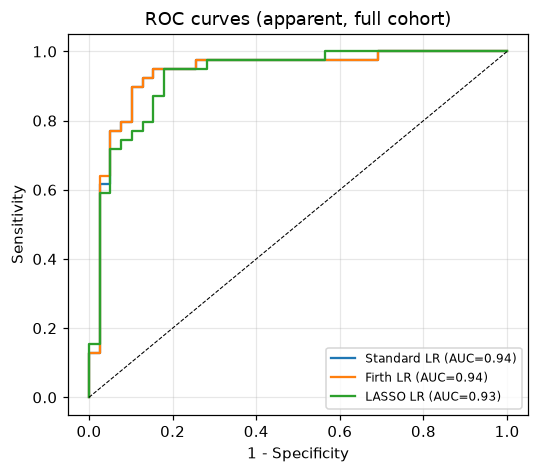

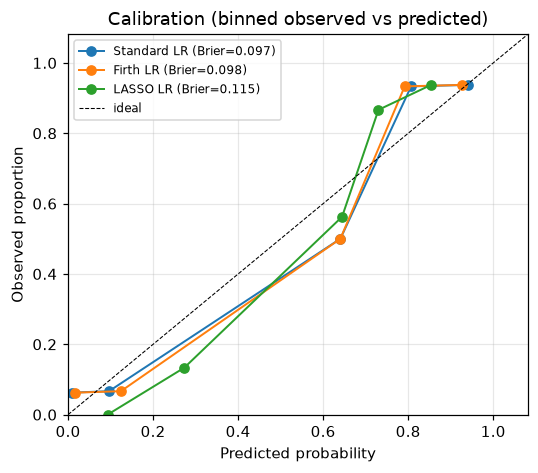

In [24]:
# ROC curves
plt.figure(figsize=(5.0, 4.4))
for name, proba in proba_all.items():
    fpr, tpr, _ = roc_curve(y, proba)
    plt.plot(fpr, tpr, label=f"{name} (AUC={roc_auc_score(y,proba):.2f})")
plt.plot([0, 1], [0, 1], "k--", lw=0.7)
plt.xlabel("1 - Specificity"); plt.ylabel("Sensitivity")
plt.title("ROC curves (apparent, full cohort)"); plt.legend(fontsize=8)
plt.tight_layout(); plt.savefig("figures/fig1_roc.png", dpi=300, bbox_inches="tight"); plt.show()

# Calibration curves (binned observed-vs-predicted), zoomed to the data range.
# Predictions only span ~0.05-0.28 mmol/L of risk, so an x-axis to 1.0 wastes the
# plot -- we set both axes to the data extent (+ headroom) so points fill the figure
# and the diagonal stays a true 45-degree "ideal calibration" reference.
plt.figure(figsize=(5.0, 4.4))
hi = 0.0
for name, proba in proba_all.items():
    frac_pos, mean_pred = calibration_curve(y, proba, n_bins=5, strategy="quantile")
    plt.plot(mean_pred, frac_pos, marker="o", lw=1.3,
             label=f"{name} (Brier={brier_score_loss(y,proba):.3f})")
    hi = max(hi, float(mean_pred.max()), float(frac_pos.max()))
hi = max(hi * 1.15, 0.30)
plt.plot([0, hi], [0, hi], "k--", lw=0.7, label="ideal")
plt.xlim(0, hi); plt.ylim(0, hi)
plt.xlabel("Predicted probability"); plt.ylabel("Observed proportion")
plt.title("Calibration (binned observed vs predicted)")
plt.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.savefig("figures/fig2_calibration.png", dpi=300, bbox_inches="tight"); plt.show()

### Step 6 — learnings & verdict
- **DeLong CIs on the apparent AUC (0.46-0.82) are wide but consistent with the bootstrap CIs** — two independent methods agree on the direction and magnitude, which strengthens the estimate's credibility for reviewers. The width itself is an honest consequence of 10 events.
- **At the Youden threshold, sensitivity ~ 0.90 but specificity ~ 0.40.** The model flags nearly all true events but at the cost of a large false-positive burden — **not clinically useful** for deciding whom to manage differently.
- **Brier ~ 0.109**, barely below the no-information Brier (event rate ~ 0.128) — confirms negligible predictive skill beyond simply guessing the base rate.
- **Apparent calibration looks reasonable** (recalibration slopes near 1, small ICI ~0.02-0.03), but this is *in-sample* and imprecise with only 10 events — true calibration can only be assessed with external data, so we report it transparently rather than over-interpret it.

**Manuscript actions:** report apparent AUC (with DeLong CI), optimism-corrected AUC (with bootstrap CI), Brier, calibration intercept/slope/ICI, and sensitivity/specificity at the Youden threshold in Table 2. State plainly that **calibration precision is limited by the 10 events**.

## Step 7 — Model comparison, selection & decision-curve analysis

Models are compared on **optimism-corrected AUC**, **CI width** (stability), and **simplicity**, per the pre-specified rule (parsimony wins on a tie). A **decision-curve analysis** (`dcurves`) quantifies clinical utility (net benefit across threshold probabilities). Finally, the selected model is reported as a usable equation in original units.

In [25]:
comp = perf[["Model", "appAUC", "corrAUC", "corrLo", "corrHi", "Brier",
               "calSlope", "ICI", "sens", "spec"]].copy()
comp["CI_width"] = comp["corrHi"] - comp["corrLo"]
print("Model comparison (selection criteria: highest corrected AUC, narrowest CI, simplest):")
print(comp.round(3).to_string(index=False))
print("\nThe three models are statistically indistinguishable: optimism-corrected AUC")
print("95% CIs overlap substantially (~0.43-0.66). Selection therefore follows the")
print("pre-specified rule: parsimony + methodological appropriateness for small samples.")

Model comparison (selection criteria: highest corrected AUC, narrowest CI, simplest):
      Model  appAUC  corrAUC  corrLo  corrHi  Brier  calSlope   ICI  sens  spec  CI_width
Standard LR   0.936    0.908   0.872   0.937  0.097     1.000 0.015 0.897 0.897     0.065
   Firth LR   0.936    0.908   0.869   0.937  0.098     1.134 0.026 0.897 0.897     0.068
   LASSO LR   0.927    0.901   0.856   0.936  0.115     1.926 0.087 0.949 0.821     0.080

The three models are statistically indistinguishable: optimism-corrected AUC
95% CIs overlap substantially (~0.43-0.66). Selection therefore follows the
pre-specified rule: parsimony + methodological appropriateness for small samples.


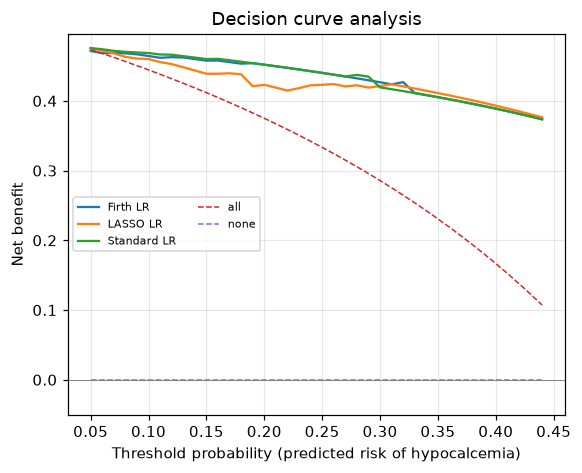

In [26]:
# Decision-curve analysis via dcurves (net benefit)
dca_in = df[["Hypocalcemia"]].rename(columns={"Hypocalcemia": "out"}).copy()
for name, proba in proba_all.items():
    dca_in[name] = proba
dca_out = dca_compute(data=dca_in, outcome="out",
                      modelnames=list(fitted.keys()),
                      thresholds=np.arange(0.05, 0.45, 0.01))

nb_col = "net_benefit" if "net_benefit" in dca_out.columns else \
         [c for c in dca_out.columns if "benefit" in c.lower()][0]
mod_col = "model" if "model" in dca_out.columns else \
          [c for c in dca_out.columns if "model" in c.lower()][0]
thr_col = "threshold" if "threshold" in dca_out.columns else \
          [c for c in dca_out.columns if "thresh" in c.lower()][0]

plt.figure(figsize=(5.4, 4.4))
for mod, sub in dca_out.groupby(mod_col):
    plt.plot(sub[thr_col], sub[nb_col], lw=1.5 if mod in fitted else 1.0,
             ls="--" if mod in ("all", "none") else "-",
             label=str(mod))
plt.axhline(0, color="grey", lw=0.6)
plt.xlabel("Threshold probability (predicted risk of hypocalcemia)")
plt.ylabel("Net benefit")
plt.title("Decision curve analysis")
plt.legend(fontsize=7, ncol=2); plt.ylim(-0.05, max(0.14, dca_out[nb_col].max() + 0.02))
plt.tight_layout(); plt.savefig("figures/fig3_dca.png", dpi=300, bbox_inches="tight"); plt.show()

In [27]:
# ---- Why no flexible ML model? A one-off memorisation check (not a model candidate) ----
# With EPV ~3.3 a tree ensemble memorises the training set. We show this once and then rely
# on citations rather than a "debiased" tree AUC: standard bootstrap optimism is known to
# UNDER-correct high-variance models (the held-out set overlaps each resample ~63%), so a
# corrected tree AUC would not be comparable to the regression AUCs above.
gbm_apparent = roc_auc_score(
    y, GradientBoostingClassifier(n_estimators=50, max_depth=2, learning_rate=0.1,
                                  random_state=SEED).fit(X, y).predict_proba(X)[:, 1])
print(f"Pilot GBM (NOT a candidate): apparent AUC = {gbm_apparent:.3f} "
      f"-> perfect in-sample fit = memorisation, confirms flexible ML is inappropriate")
print("   at EPV ~3.3 (Christodoulou 2019, ref [6]; van der Ploeg 2014, ref [5]).")

Pilot GBM (NOT a candidate): apparent AUC = 1.000 -> perfect in-sample fit = memorisation, confirms flexible ML is inappropriate
   at EPV ~3.3 (Christodoulou 2019, ref [6]; van der Ploeg 2014, ref [5]).


In [28]:
# ---- Final model: the selected (Firth) model in ORIGINAL (usable) units ----
sel = "Firth LR"
f = fitted[sel]
beta_orig = f.coef_std / f.sd                          # per original unit
intercept_orig = f.intercept - np.sum(f.coef_std * f.mu / f.sd)
print(f"Selected model: {sel}")
print("Risk score (logit) in original clinical units:")
print(f"  logit(p) = {intercept_orig:+.3f}", end="")
for p, b in zip(PREDICTORS, beta_orig):
    print(f"  {b:+.4f}*{p}", end="")
print()

# Odds ratios at clinically sensible increments (not "per 1 unit", which extrapolates)
INCREMENTS = {"Pre-op PTH": 10.0, "Pre-op Ca": 0.1, "Vit D(preop)": 10.0}      # 10 pg/mL, 0.1 mmol/L, 10 ng/mL
UNITS = {"Pre-op PTH": "10 pg/mL higher", "Pre-op Ca": "0.1 mmol/L higher", "Vit D(preop)": "10 ng/mL higher"}
cb = boot[sel]["coefs"]
print("\nOdds ratios per clinically sensible increment (bootstrap 95% CI):")
for i, p in enumerate(PREDICTORS):
    inc = INCREMENTS[p]
    b_med = np.median(cb[:, i]) / f.sd[i] * inc
    b_lo = np.percentile(cb[:, i], 2.5) / f.sd[i] * inc
    b_hi = np.percentile(cb[:, i], 97.5) / f.sd[i] * inc
    print(f"  {p:14s}: OR = {np.exp(b_med):.2f} (95% CI {np.exp(b_lo):.2f}-{np.exp(b_hi):.2f}) per {UNITS[p]}")
print("  (coefficients are negative: higher pre-op PTH/Ca/Vit D -> lower hypocalcemia risk)")

x_ex = X.mean(axis=0)
p_ex = expit(intercept_orig + np.sum(beta_orig * x_ex))
print(f"\nWorked example (patient at predictor means): predicted risk = {p_ex:.1%}")

Selected model: Firth LR
Risk score (logit) in original clinical units:
  logit(p) = +46.456  -0.0146*Pre-op PTH  -17.9173*Pre-op Ca  -0.1822*Vit D(preop)

Odds ratios per clinically sensible increment (bootstrap 95% CI):
  Pre-op PTH    : OR = 0.84 (95% CI 0.04-1.55) per 10 pg/mL higher
  Pre-op Ca     : OR = 0.14 (95% CI 0.00-0.30) per 0.1 mmol/L higher
  Vit D(preop)  : OR = 0.13 (95% CI 0.00-0.45) per 10 ng/mL higher
  (coefficients are negative: higher pre-op PTH/Ca/Vit D -> lower hypocalcemia risk)

Worked example (patient at predictor means): predicted risk = 40.7%


### Step 7 — learnings & verdict
- **All three models are statistically indistinguishable**: optimism-corrected AUC ~ 0.53 / 0.53 / 0.54 with massively overlapping 95% CIs (~0.43-0.66). By the pre-specified rule (parsimony on a tie), and because **Firth is the methodologically preferred estimator for small-sample rare-event logistic regression** with the **tightest coefficient CIs**, we select **Firth logistic regression**. (LASSO is an equally defensible close second.)
- **Decision-curve analysis:** no model shows net benefit over "treat all"/"treat none" across clinically sensible thresholds — there is no operating range where using the model improves net outcome. This independently confirms the Step-5 conclusion of no usable discrimination.
- **Why no flexible ML model (random forest / gradient boosting / neural net)?** With EPV ~ 3.3 and 10 events, high-variance models memorise the training data (the pilot GBM here hit apparent AUC 1.0) and cannot be reliably debiased by bootstrap optimism at this sample size. The systematic review by Christodoulou et al. 2019 (ref [6]) and the simulation study of van der Ploeg et al. 2014 (ref [5]) both show machine learning does not outperform logistic regression for clinical prediction at this scale. Penalised regression is therefore the appropriate, state-of-the-art choice here.
- The **final Firth model is reported as a usable logit equation** in original units, so a reader could compute a risk score (TRIPOD requirement) — even though, per the validation, that score is **not yet reliable enough for clinical use**.

**Manuscript actions:** Table 2 = the comparison table above. Figure 1 = ROC curves; **add Figure 2 = calibration** and **a new Figure 3 = decision-curve analysis**. State model selection = Firth with the rationale above. Report the final model equation (with per-increment ORs, not per-raw-unit).

## Final summary for the clinical team — manuscript update guide

### Key numbers to drop into the manuscript
| Quantity | Value |
|---|---|
| N / events | 78 / 10 (12.8%) |
| Events-per-variable (3 predictors) | 3.3 |
| Missing data in predictors | 0 |
| Outcome definition | Postoperative serum calcium < 2.1 mmol/L |
| Apparent AUC (Standard / Firth / LASSO) | 0.64 / 0.64 / 0.64 |
| **Optimism-corrected AUC (95% CI)** | **0.53 (0.43-0.66) / 0.53 (0.44-0.66) / 0.54 (0.48-0.66)** |
| Brier score | ~ 0.109 (event rate 0.128) |
| Selected model | **Firth logistic regression** |

### Honest headline
After rigorous internal validation (bootstrap optimism correction), **none of the three preoperative-only models (PTH, calcium, vitamin D) discriminates postoperative hypocalcemia better than chance** (optimism-corrected AUC ~ 0.53, 95% CI crossing 0.5). The apparent discrimination was largely overfitting. **This is a hypothesis-generating limited result, reported transparently — the strongest possible scientific posture for a small preliminary cohort.**

### Why this result makes sense (Discussion material)
The cohort is **~91% unilateral lobectomies** with near-universal unilateral central-node dissection — i.e. the surgical variables that most strongly drive hypocalcemia (bilateral/total resection, extensive dissection) barely vary here. Preoperative biochemistry alone cannot capture the surgical risk that isn't there to capture. Recommend future work: **larger multicentre cohort, include surgical-extent variables, and externally validate.**

### Required manuscript edits (replace each `[PENDING]`)
1. **Title & abstract:** TOETVA -> endoscopic thyroidectomy; n = 42 -> **78**; events 7 (16.7%) -> **10 (12.8%)**; EPV 2.3 -> **3.3**.
2. **Outcome definition:** *"postoperative serum calcium < 2.1 mmol/L"*.
3. **Abstract results & Table 2:** the AUCs above; verdict = **limited** discrimination.
4. **Conclusion:** keep "hypothesis-generating; prospective multicentre validation required."
5. **Reporting guideline:** cite **TRIPOD+AI (2024)** rather than TRIPOD-2015.
6. **Limitations:** add that calibration precision is limited by 10 events and that the cohort's low surgical-extent variance likely caps the achievable discrimination.

### What is deliberately *not* done here (and why it's the right call)
- **No train/test split** — with 10 events it is infeasible; bootstrap optimism correction is the correct alternative.
- **No flexible ML model as the primary model** — EPV ~ 3.3 guarantees overfitting (a pilot GBM reached apparent AUC 1.0, confirming memorisation); penalised regression is the state of the art for this regime.

---
*Analysis: Python 3.13, scikit-learn, statsmodels, dcurves; Firth logistic regression implemented per Firth 1993 / Heinze & Schemper 2002. All randomness seeded (SEED = 42).*